# 1. Find competition/season with full matches dataset.

In [51]:
import pandas as pd
from statsbombpy import sb
import warnings
warnings.filterwarnings("ignore", message="credentials were not supplied")

# Get all free competitions
free_comps = sb.competitions()
men_comps = free_comps[free_comps['competition_gender'] == 'male']

# Prepare list to store match counts
match_counts = []

# Loop over each competition_id + season_id
for comp_id, season_id in zip(men_comps['competition_id'], men_comps['season_id']):
    # Count actual matches
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        'competition_id': comp_id,
        'season_id': season_id,
        'matches_count': matches_count
    })

# Convert to DataFrame
match_counts_df = pd.DataFrame(match_counts)

# Join metadata from men_comps
metadata_cols = ['competition_id', 'season_id', 'competition_name', 'season_name',
                 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']
match_counts_df = match_counts_df.merge(men_comps[metadata_cols], on=['competition_id', 'season_id'], how='left')

# Sort by actual matches
match_counts_df.sort_values('matches_count', ascending=False, inplace=True)
match_counts_df.reset_index(drop=True, inplace=True)

In [52]:
match_counts_df[['competition_id', 'competition_name', 'season_id', 'season_name',
                 'matches_count', 'match_updated', 'match_updated_360',
                 'match_available_360', 'match_available']].head(10)

,competition_id,competition_name,season_id,season_name,matches_count,match_updated,match_updated_360,match_available_360,match_available
0,12,Serie A,27,2015/2016,380,2025-07-21T05:01:00.434081,None,None,2025-07-21T05:01:00.434081
1,2,Premier League,27,2015/2016,380,2025-04-23T14:36:29.347042,2021-06-13T16:17:31.694,None,2025-04-23T14:36:29.347042
2,11,La Liga,27,2015/2016,380,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
3,7,Ligue 1,27,2015/2016,377,2024-12-16T08:48:23.066123,None,None,2024-12-16T08:48:23.066123
4,9,1. Bundesliga,27,2015/2016,306,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
5,1238,Indian Super league,108,2021/2022,115,2024-09-29T17:46:01.175308,None,None,2024-09-29T17:46:01.175308
6,43,FIFA World Cup,3,2018,64,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
7,43,FIFA World Cup,106,2022,64,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
8,1267,African Cup of Nations,107,2023,52,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
9,55,UEFA Euro,43,2020,51,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309


In [53]:
import pandas as pd
from statsbombpy import sb
import warnings
warnings.filterwarnings("ignore", message="credentials were not supplied")

# Premier League 2015/2016
competition_id = 2
season_id = 27

# Load all matches from StatsBomb open data
matches = sb.matches(competition_id=competition_id, season_id=season_id)

In [54]:
len(matches)

380

In [56]:
matches.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3754058,2016-01-02,16:00:00.000,England - Premier League,2015/2016,Leicester City,AFC Bournemouth,0,0,available,processing,2021-10-29T23:44:19.940296,2021-06-12T16:17:31.694,20,Regular Season,King Power Stadium,Andre Marriner,Claudio Ranieri,Eddie Howe,1.1.0,2,2
1,3754245,2015-10-17,16:00:00.000,England - Premier League,2015/2016,West Bromwich Albion,Sunderland,1,0,available,scheduled,2022-12-01T13:09:17.044015,2021-06-13T16:17:31.694,9,Regular Season,The Hawthorns,Martin Atkinson,Tony Pulis,Sam Allardyce,1.1.0,2,2
2,3754136,2015-12-19,18:30:00.000,England - Premier League,2015/2016,Newcastle United,Aston Villa,1,1,available,scheduled,2020-11-12T23:48:19.757269,2021-06-13T16:17:31.694,17,Regular Season,St. James'' Park,Martin Atkinson,Steve McClaren,Rémi Garde,1.1.0,2,2
3,3754037,2016-04-30,16:00:00.000,England - Premier League,2015/2016,Everton,AFC Bournemouth,2,1,available,processing,2021-07-07T17:59:57.456,2021-06-12T16:17:31.694,36,Regular Season,Goodison Park,Neil Swarbrick,Roberto Martínez Montoliú,Eddie Howe,1.1.0,2,2
4,3754039,2016-02-13,16:00:00.000,England - Premier League,2015/2016,Crystal Palace,Watford,1,2,available,processing,2021-07-25T18:09:51.386,2021-06-12T16:17:31.694,26,Regular Season,Selhurst Park,Robert Madley,Alan Pardew,Enrique Sánchez Flores,1.1.0,2,2


In [58]:
match_id = 3754058
events = sb.events(match_id=match_id)

In [60]:
len(events)

3576

In [61]:
events.head(6)

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9153e9f4-f69c-4e04-8f64-505592e212cd,1,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Leicester City,22,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4141, 'lineup': [{'player': {'id...",AFC Bournemouth,28,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,[100362ee-9311-4187-bd8a-0201d9db2565],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100362ee-9311-4187-bd8a-0201d9db2565,4,NaN,NaN,3754058,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Leicester City,22,[06a9a4dc-d9c9-40f6-bd89-437ba7fe682d],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a645ce0-af88-4dfc-8f97-82d3770bc4ae,1927,NaN,NaN,3754058,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Free Kick,NaN,NaN,NaN,82,AFC Bournemouth,28,[a8059850-8edc-4273-a102-1f6ad3ae782d],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a8059850-8edc-4273-a102-1f6ad3ae782d,1928,NaN,NaN,3754058,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [63]:
start = len(events) // 2 
end = start + 6        

events.iloc[start:end]

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
1788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b7d19ac2-ef01-4f71-ad48-4cae24069c13,3023,NaN,"[50.2, 15.2]",3754058,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,Robert Huth,40123.0,Left Center Back,153,Leicester City,22,[c06cb35e-019b-476e-a1da-17cc305cebb8],38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:31:38.204,Ball Receipt*,NaN
1789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7347cf6c-1688-427e-a5c9-0e11e5fbdafc,3026,NaN,"[46.8, 41.1]",3754058,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,Wes Morgan,3813.0,Right Center Back,153,Leicester City,22,[d2462a8e-7415-4533-a235-7257018f914d],41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:31:41.412,Ball Receipt*,NaN
1790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,527bfe87-b9ad-49bf-b5d4-b336b3b0de7c,3029,NaN,"[64.0, 62.1]",3754058,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,Danny Drinkwater,3662.0,Right Center Midfield,153,Leicester City,22,[67f544fe-557d-49b4-9080-bc7cb81c85ca],45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:31:45.131,Ball Receipt*,NaN
1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e933d582-83a1-493a-9c27-bbfb67179264,3033,NaN,"[96.1, 31.4]",3754058,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,Jamie Vardy,10960.0,Left Center Forward,153,Leicester City,22,[1aea544e-26f5-461a-a94e-6b5cd9bc299b],49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:31:49.335,Ball Receipt*,NaN
1792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6102adb8-270e-43c3-b2aa-95f58d273638,3036,NaN,"[99.4, 11.6]",3754058,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,Nathan Dyer,3631.0,Right Center Forward,153,Leicester City,22,[baa13ef5-2fcc-46a2-b0b8-31174b187a53],51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:31:51.679,Ball Receipt*,NaN

In [66]:
import pandas as pd
from statsbombpy import sb
from pathlib import Path
from tqdm import tqdm  # progress bar

# Folder to cache event files
CACHE_DIR = Path("statsbomb_cache/events")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Example: matches DataFrame for a season
# matches = sb.matches(competition_id=9, season_id=281)  # Bundesliga 2023/24, for example

def load_events_for_match(match_id):
    """Load events for a match, with caching."""
    cache_file = CACHE_DIR / f"{match_id}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)
    events = sb.events(match_id=match_id)
    events.to_parquet(cache_file)
    return events

# Loop over all matches and build a full dataset
all_events_list = []
for match_id in tqdm(matches['match_id'], desc="Downloading events"):
    match_events = load_events_for_match(match_id)
    # Add a column to identify the match
    match_events['match_id'] = match_id
    all_events_list.append(match_events)

# Concatenate into a single DataFrame
full_events_df = pd.concat(all_events_list, ignore_index=True)

# Save to disk if desired
full_events_df.to_parquet("full_season_events.parquet")

print("Full events dataset shape:", full_events_df.shape)

Full events dataset shape: (1313783, 118)


In [74]:
# Check columns
print(full_events_df.columns)

# Look at the first 5 rows
full_events_df.head(5)

# Optional: see the event types in your dataset
event_types = full_events_df['type'].apply(lambda x: x.get('name') if isinstance(x, dict) else x)
print(event_types.value_counts())

Index(['ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'carry_end_location', 'clearance_aerial_won', 'clearance_body_part',
       'clearance_head', 'clearance_left_foot', 'clearance_right_foot',
       'counterpress', 'dribble_nutmeg',
       ...
       'half_start_late_video_start', 'goalkeeper_lost_in_play',
       'goalkeeper_penalty_saved_to_post', 'goalkeeper_saved_to_post',
       'team_name', 'player_name', 'event_type', 'receiver', 'pass_end_x',
       'pass_end_y'],
      dtype='object', length=124)
type
Pass                 368619
Ball Receipt*        340324
Carry                276949
Pressure             115402
Ball Recovery         40943
Duel                  32290
Clearance             21645
Block                 14839
Dribble               13721
Goal Keeper           11777
Miscontrol            10786
Dispossessed          10520
Shot                   9908
Foul Committed         9512
Foul Won               9112
Interception           8920
Dribbled Past  

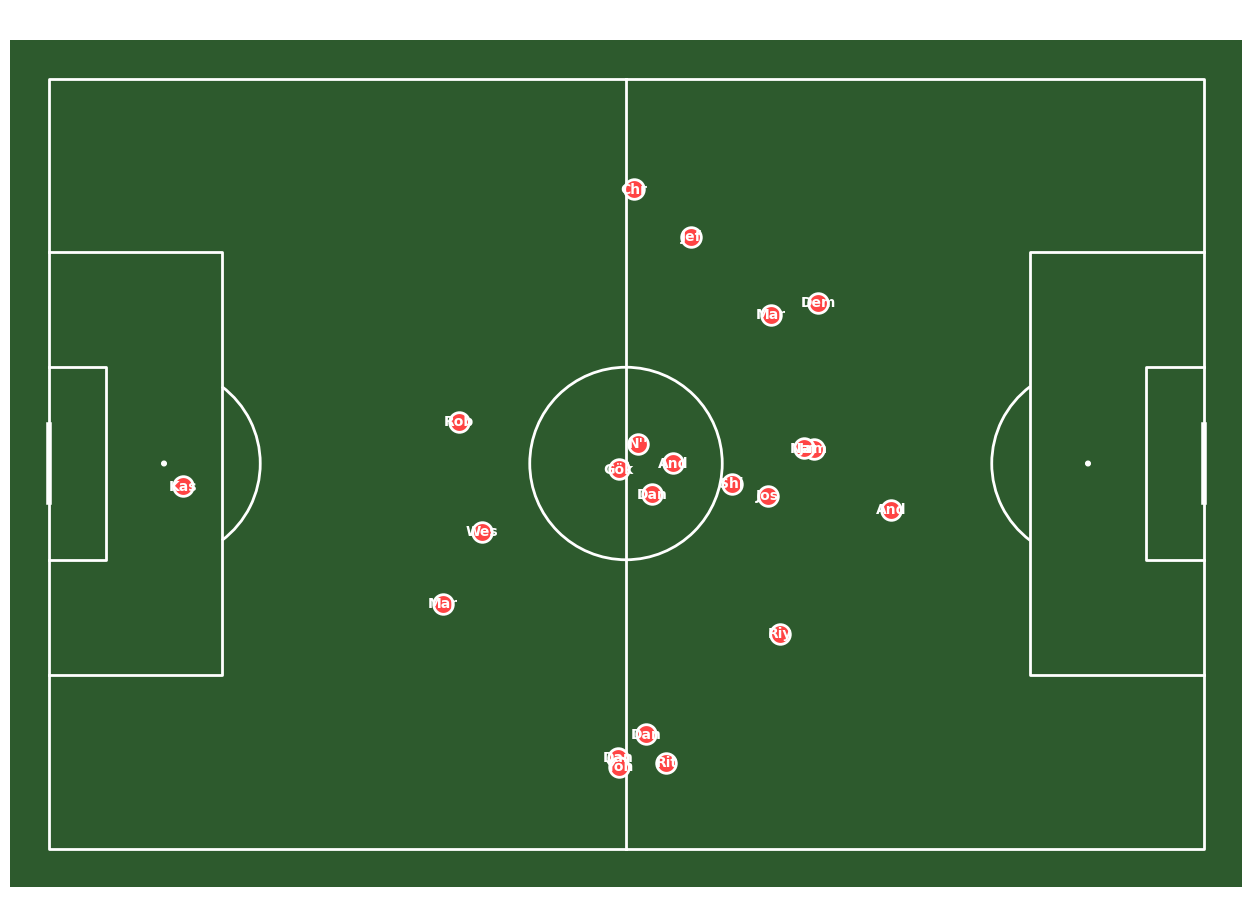

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from collections import defaultdict

# -----------------------------
# 1️⃣ Select team
# -----------------------------
team_name = full_events_df['team_name'].unique()[0]  # first team, change if you want
team_passes = full_events_df[
    (full_events_df['team_name'] == team_name) &
    (full_events_df['event_type'] == 'Pass')
].copy()

# -----------------------------
# 2️⃣ Compute average player positions
# -----------------------------
player_positions = defaultdict(list)

for idx, row in team_passes.iterrows():
    player = row['player_name']
    start = row.get('location')
    if start is not None and isinstance(start, (list, np.ndarray)) and len(start) == 2:
        player_positions[player].append(start)

avg_positions = {}
for player, positions in player_positions.items():
    if len(positions) >= 15:  # only include active players
        positions_array = np.array(positions)
        avg_positions[player] = (positions_array[:, 0].mean(), positions_array[:, 1].mean())

# -----------------------------
# 3️⃣ Count pass connections
# -----------------------------
pass_connections = defaultdict(int)
for idx, row in team_passes.iterrows():
    passer = row['player_name']
    receiver = row.get('receiver')
    if isinstance(receiver, dict):
        receiver = receiver.get('name')
    if passer in avg_positions and receiver in avg_positions:
        pass_connections[(passer, receiver)] += 1

# -----------------------------
# 4️⃣ Draw the pass network
# -----------------------------
fig, ax = plt.subplots(figsize=(16,11))
pitch = Pitch(pitch_type='statsbomb', pitch_color='#2d5a2d', line_color='white')
pitch.draw(ax=ax)

# Draw pass connections
min_passes = 5  # adjust if too few connections
significant_connections = {k:v for k,v in pass_connections.items() if v >= min_passes}
max_passes = max(significant_connections.values()) if significant_connections else 1

for (passer, receiver), count in significant_connections.items():
    passer_pos = avg_positions[passer]
    receiver_pos = avg_positions[receiver]
    ax.plot(
        [passer_pos[0], receiver_pos[0]],
        [passer_pos[1], receiver_pos[1]],
        color='white',
        linewidth=1 + (count / max_passes) * 8,
        alpha=0.3 + (count / max_passes) * 0.6,
        zorder=2
    )

# Draw players
for player, pos in avg_positions.items():
    ax.scatter(pos[0], pos[1], s=200, color='#FF4444', edgecolor='white', linewidth=2, zorder=5)
    ax.text(pos[0], pos[1], player[:3], color='white', ha='center', va='center', fontweight='bold', zorder=6)

# Title
ax.set_title(f"{team_name} Pass Network", fontsize=20, color='white')

plt.show()

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# -----------------------------
# Match and team
# -----------------------------
match_id = 3754136
team_name = "Aston Villa"

# -----------------------------
# Filter passes
# -----------------------------
passes = full_events_df[
    (full_events_df["match_id"] == match_id) &
    (full_events_df["team_name"] == team_name) &
    (full_events_df["event_type"] == "Pass")
].copy()

print("Total passes:", len(passes))


# -----------------------------
# Extract coordinates
# -----------------------------
passes["start_x"] = passes["location"].apply(lambda x: x[0])
passes["start_y"] = passes["location"].apply(lambda x: x[1])

passes["end_x"] = passes["pass_end_location"].apply(lambda x: x[0])
passes["end_y"] = passes["pass_end_location"].apply(lambda x: x[1])


# -----------------------------
# Player average positions
# -----------------------------
player_positions = (
    passes.groupby("player_name")[["start_x","start_y"]]
    .mean()
    .reset_index()
)


# -----------------------------
# Pass counts between players
# -----------------------------
pass_between = (
    passes.groupby(["player_name","pass_recipient_name"])
    .size()
    .reset_index(name="pass_count")
)

# remove weak links
pass_between = pass_between[pass_between["pass_count"] >= 2]


# -----------------------------
# Merge player coordinates
# -----------------------------
pass_between = pass_between.merge(
    player_positions,
    on="player_name"
)

pass_between = pass_between.merge(
    player_positions,
    left_on="pass_recipient_name",
    right_on="player_name",
    suffixes=("_start","_end")
)

# remove duplicate column
pass_between = pass_between.drop(columns=["player_name_end"])


# -----------------------------
# Plot pitch
# -----------------------------
fig, ax = plt.subplots(figsize=(14,10))

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#22312b",
    line_color="white"
)

pitch.draw(ax=ax)


# -----------------------------
# Draw pass lines
# -----------------------------
if len(pass_between) > 0:

    max_pass = pass_between["pass_count"].max()

    for _, row in pass_between.iterrows():

        width = (row.pass_count / max_pass) * 10

        ax.plot(
            [row.start_x_start, row.start_x_end],
            [row.start_y_start, row.start_y_end],
            color="white",
            linewidth=width,
            alpha=0.7
        )


# -----------------------------
# Draw players
# -----------------------------
for _, row in player_positions.iterrows():

    ax.scatter(
        row.start_x,
        row.start_y,
        s=400,
        color="#d62728",
        edgecolor="white",
        linewidth=2
    )

    ax.text(
        row.start_x,
        row.start_y,
        row.player_name.split()[-1],
        color="white",
        ha="center",
        va="center",
        fontsize=9
    )


ax.set_title(
    f"{team_name} Pass Network\nMatch {match_id}",
    fontsize=18,
    color="white"
)

plt.show()

Total passes: 477


KeyError: 'pass_recipient_name'

In [83]:
print(passes[["player_name","receiver","start_x","start_y"]].head())

Empty DataFrame
Columns: [player_name, receiver, start_x, start_y]
Index: []


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from mplsoccer import Pitch

# --------------------------------
# PARAMETERS
# --------------------------------
shot_window = 15
pitchLengthX = 120
pitchWidthY = 80


# --------------------------------
# Helper function
# --------------------------------
def in_range(pass_time, start, finish):
    return True in ((start < pass_time) & (pass_time < finish)).unique()


# --------------------------------
# Identify teams and matches
# --------------------------------
teams = full_events_df["team_name"].dropna().unique()
match_ids = full_events_df["match_id"].dropna().unique()

passshot_df = pd.DataFrame(
    columns=["Team","Passes","Shots","Goals","Danger Passes"]
)

danger_passes_by = {}
number_of_matches = {}


# --------------------------------
# Loop through matches
# --------------------------------
for match_id in match_ids:

    dfall = full_events_df[full_events_df["match_id"] == match_id]

    for theteam in teams:

        df = dfall[dfall["team_name"] == theteam]

        passes_match = df[df["event_type"] == "Pass"]
        shots_match = df[df["event_type"] == "Shot"]

        if len(df) == 0:
            continue

        # time in seconds
        shot_times = shots_match["minute"]*60 + shots_match["second"]
        shot_start = shot_times - shot_window

        pass_times = passes_match["minute"]*60 + passes_match["second"]

        pass_to_shot = pass_times.apply(
            lambda x: in_range(x, shot_start, shot_times)
        )

        iscorner = passes_match["pass_type_name"] == "Corner"

        danger_passes = passes_match[
            np.logical_and(pass_to_shot, np.logical_not(iscorner))
        ]

        # store danger passes
        if theteam in danger_passes_by:

            danger_passes_by[theteam] = pd.concat(
                [danger_passes_by[theteam], danger_passes]
            )

            number_of_matches[theteam] += 1

        else:

            danger_passes_by[theteam] = danger_passes
            number_of_matches[theteam] = 1


        goals = len(
            shots_match[shots_match["shot_outcome_name"] == "Goal"]
        )


        passshot_df = pd.concat([
            passshot_df,
            pd.DataFrame({
                "Team":[theteam],
                "Passes":[len(passes_match)],
                "Shots":[len(shots_match)],
                "Goals":[goals],
                "Danger Passes":[len(danger_passes)]
            })
        ])


# --------------------------------
# PASSES vs SHOTS PLOT
# --------------------------------
fig, ax = plt.subplots()

ax.scatter(
    passshot_df["Passes"],
    passshot_df["Shots"],
    color="grey",
    s=20
)

ax.set_xlabel("Passes")
ax.set_ylabel("Shots")

ax.set_title("Passes vs Shots")

# regression line
model_fit = smf.ols(
    formula="Shots ~ Passes",
    data=passshot_df
).fit()

print(model_fit.summary())

b = model_fit.params

x = np.arange(0,1000)
y = b[0] + b[1]*x

ax.plot(x,y,color="black")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


# --------------------------------
# POISSON REGRESSION FOR GOALS
# --------------------------------
poisson_model = smf.glm(
    formula="Goals ~ Passes + Team",
    data=passshot_df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())


# --------------------------------
# PASS HEATMAPS
# --------------------------------
H_Pass = {}
x_all = []
y_all = []

for team in teams:

    if team not in danger_passes_by:
        continue

    dp = danger_passes_by[team]

    x = []
    y = []

    for _, apass in dp.iterrows():

        if isinstance(apass["location"], list):

            x.append(apass["location"][0])
            y.append(pitchWidthY - apass["location"][1])

    H_Pass[team] = np.histogram2d(
        y, x,
        bins=5,
        range=[[0,pitchWidthY],[0,pitchLengthX]]
    )

    x_all += x
    y_all += y


H_Pass_All = np.histogram2d(
    y_all,
    x_all,
    bins=5,
    range=[[0,pitchWidthY],[0,pitchLengthX]]
)


# --------------------------------
# PLOT HEATMAPS
# --------------------------------
for team in H_Pass:

    fig, ax = plt.subplots(figsize=(8,5))

    pitch = Pitch(
        pitch_type="statsbomb",
        line_color="black"
    )

    pitch.draw(ax=ax)

    heat = (
        H_Pass[team][0] / number_of_matches[team]
        - H_Pass_All[0] / (len(match_ids)*2)
    )

    pos = ax.imshow(
        heat,
        extent=[0,120,0,80],
        cmap="seismic",
        vmin=-3,
        vmax=3,
        aspect="auto"
    )

    ax.set_title(f"Danger Pass Locations: {team}")

    fig.colorbar(pos, ax=ax)

    plt.show()

KeyError: 'pass_type_name'